# Fashion MNIST

## Integrantes:

Pedro Henrique Macedo Antunes

Kevin Teixeira Carvalho

Diogo Lima de Oliveira

## Fonte:
 https://www.kaggle.com/datasets/zalando-research/fashionmnist

## Objetivo:
 Gerar um modelo de ML classificador, capaz de classisficar diferentes imagens do dataset 'Fashion MNIST', feito para benchmark de modelos de ML, assim como o MNIST, porém mais complexo, por que o MNIST é tão simples que qualquer modelo consegue uma boa pontuação com ele.

 "The original MNIST dataset contains a lot of handwritten digits. Members of the AI/ML/Data Science community love this dataset and use it as a benchmark to validate their algorithms. In fact, MNIST is often the first dataset researchers try. "If it doesn't work on MNIST, it won't work at all", they said. "Well, if it does work on MNIST, it may still fail on others."

Zalando seeks to replace the original MNIST dataset"

## Atributo alvo:
Tipo de peça de roupa (shirt, t-shirt, trouser, dress ...)

## Atributo preditivo:
Imagem (cada pixel)

## Tipo da tarefa:
Classificação

## Compreensão e análise de dados
Nessa parte do notebook, iremos visualizar e analisar os dados.

In [ ]:
import sklearn
import kagglehub
import pandas as pd

In [ ]:
# Salvando o dataset a partir do kaggle.
train_df = kagglehub.dataset_load(
    kagglehub.KaggleDatasetAdapter.PANDAS,
    "zalando-research/fashionmnist",
    "fashion-mnist_train.csv"
)

test_df = kagglehub.dataset_load(
    kagglehub.KaggleDatasetAdapter.PANDAS,
    "zalando-research/fashionmnist",
    "fashion-mnist_test.csv"
)

print(train_df.shape)
print(test_df.shape)

Using Colab cache for faster access to the 'fashionmnist' dataset.
Using Colab cache for faster access to the 'fashionmnist' dataset.
(60000, 785)
(10000, 785)


## Analisando o tipo de dado e balanceamento do dataset

In [ ]:
content = train_df.iloc[0]
print(content)

label       2
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Name: 0, Length: 785, dtype: int64


In [ ]:
print(train_df['label'].value_counts())
print(test_df['label'].value_counts())

label
2    6000
9    6000
6    6000
0    6000
3    6000
4    6000
5    6000
8    6000
7    6000
1    6000
Name: count, dtype: int64
label
0    1000
1    1000
2    1000
3    1000
8    1000
6    1000
5    1000
4    1000
7    1000
9    1000
Name: count, dtype: int64


Isso nos mostra que, o dado é no formato:

label, (imagem)

Em que label é o rótulo do dado, e imagem são os pixels da imagem 28x28, representados por números inteiros int64.

Além disso, o dataset é balanceado.


## Análise do df como um todo

In [ ]:
# Junta o conjunto de teste e treino
df = pd.concat([train_df, test_df], ignore_index=True)
count, size = df.shape
# Separa label dos pixels
X = df.drop('label', axis=1)
y = df['label']

print("Valores ausentes?")
# Se há valores ausentes, dentro das imagens
print(df.isnull().sum().sum())

print("Imagens duplicadas?")
# Se há valores duplicados
dup = df.duplicated().sum()
print(dup)
dup = (dup/count*100)*1000
dup = round(dup)
dup = dup/1000
print(f"Porcentagem: {dup}%")

# Os valores dos pixels estão entre 0 e 255?
X_desc = X.describe()
print(X_desc.loc[['min', 'max']])

Valores ausentes?
0
Imagens duplicadas?
53
Porcentagem: 0.076%
     pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
min     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
max    16.0    45.0   226.0   185.0   227.0   230.0   247.0   255.0   254.0   

     pixel10  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
min      0.0  ...       0.0       0.0       0.0       0.0       0.0       0.0   
max    255.0  ...     255.0     255.0     255.0     255.0     255.0     255.0   

     pixel781  pixel782  pixel783  pixel784  
min       0.0       0.0       0.0       0.0  
max     255.0     255.0     255.0     170.0  

[2 rows x 784 columns]


Ao analisar os dados, é possível concluir que, não há valores ausente e os pixels sempre tem de 0 a 255 em sua escala.

Porém, existem imagens duplicadas, interessante, vamos explorar elas.

Queremos saber, primeiramente, se há alguma imagem duplicada no test e train

In [ ]:
print(train_df.duplicated().sum())
print(test_df.duplicated().sum())

43
1


Como existem mais imagens duplicadas no df junto no que nos dfs separados e somados, é possível concluir que existem sim imagens iguais no train e no test!

#Gráficos

In [ ]:
# Importações
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

<Axes: >

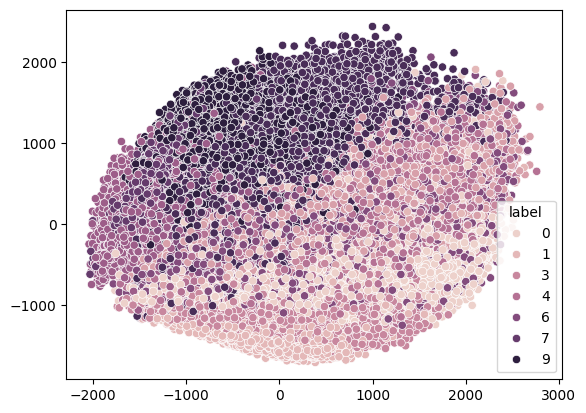

In [ ]:
pca = PCA(n_components=2); X_pca = pca.fit_transform(X)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y)

A partir do gráfico, é possível ver que enquanto é possível distinguir cada classe, ainda há um overlap entre elas. Ou seja, erros nas áreas com overlap

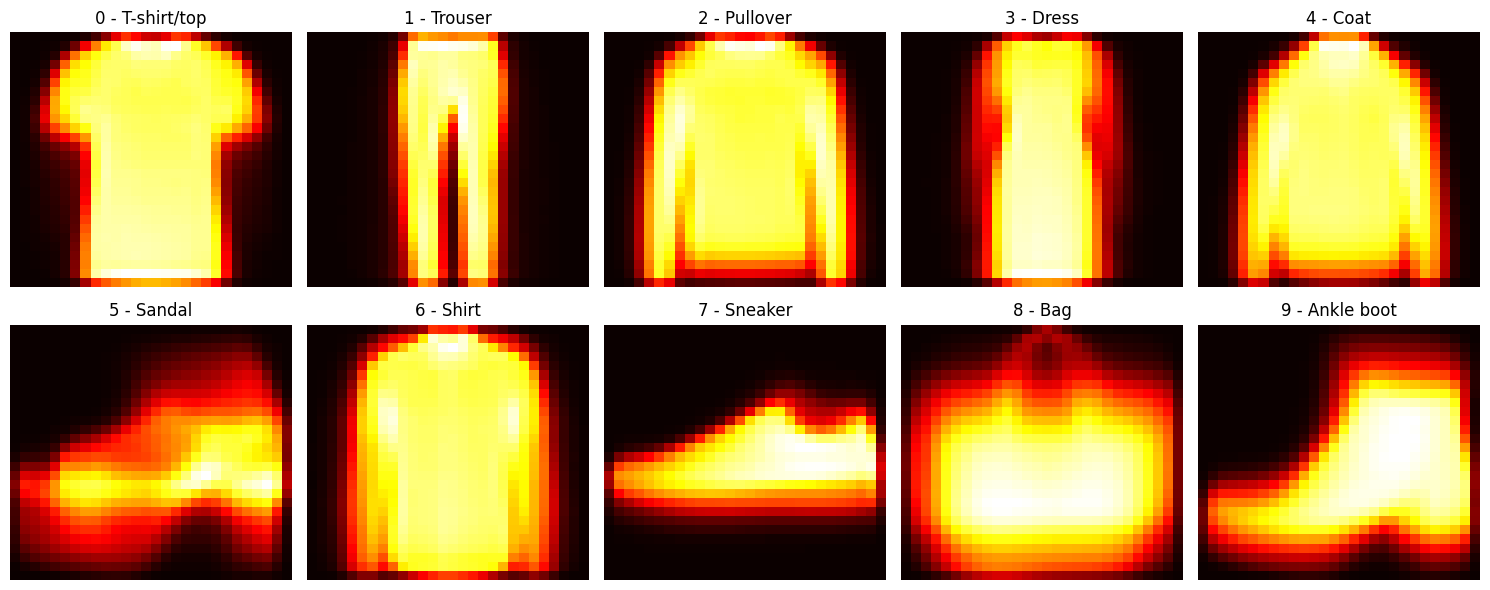

In [ ]:
X = df.drop('label', axis=1)
y = df['label']

class_means = X.groupby(y).mean()

# Nome de cada rótulo
labels_names = {
    0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
    5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'
}

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, ax in enumerate(axes):

    img_media = class_means.loc[i].values.reshape(28, 28)

    heatmap = sns.heatmap(img_media, ax=ax, cmap='hot', cbar=False,
                          xticklabels=False, yticklabels=False)

    ax.set_title(f'{i} - {labels_names[i]}', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

A partir do heatmap é possível enxergar a "média" de cada peça, é possível ver como, realmente, existe um overlap entre algumas classes, principalmente com Trouser, Coat e Shirt, e Sandal, Sneaker e Ankle Boot

# Pré-Processamento

**Normalização**:

Problema:
Os valores dos pixels das imagens variam entre 0 e 255, o que pode dificultar o treinamento da rede neural, tornando a convergência mais lenta e menos estável.

Tratamento:
Foi realizada a normalização dos pixels, dividindo todos os valores por 255, fazendo com que passem a variar entre 0 e 1.

Motivo:
Porque a normalização coloca todas as entradas na mesma escala, facilitando o aprendizado da rede neural, acelerando a convergência do treinamento e contribuindo para uma maior estabilidade do processo de otimização.

In [ ]:
X = X / 255.0
print(X.iloc[:5])

   pixel1  pixel2  pixel3    pixel4    pixel5  pixel6  pixel7    pixel8  \
0     0.0     0.0     0.0  0.000000  0.000000     0.0     0.0  0.000000   
1     0.0     0.0     0.0  0.000000  0.000000     0.0     0.0  0.000000   
2     0.0     0.0     0.0  0.000000  0.000000     0.0     0.0  0.019608   
3     0.0     0.0     0.0  0.003922  0.007843     0.0     0.0  0.000000   
4     0.0     0.0     0.0  0.000000  0.000000     0.0     0.0  0.000000   

   pixel9  pixel10  ...  pixel775  pixel776  pixel777  pixel778  pixel779  \
0     0.0      0.0  ...  0.000000       0.0       0.0  0.000000  0.000000   
1     0.0      0.0  ...  0.000000       0.0       0.0  0.000000  0.000000   
2     0.0      0.0  ...  0.000000       0.0       0.0  0.117647  0.168627   
3     0.0      0.0  ...  0.011765       0.0       0.0  0.000000  0.000000   
4     0.0      0.0  ...  0.000000       0.0       0.0  0.000000  0.000000   

   pixel780  pixel781  pixel782  pixel783  pixel784  
0  0.000000       0.0       0.0 

**Remoção de Duplicatas**

Problema: O conjunto de treinamento possui algumas duplicatas (imagens identicas umas as outras) atrapalhando na identificação de padrões, por ele já ter noção da classe da imagem, trazendo uma ideia mais de memorização.

Tratamento: A Remoção de Duplicatas faz a detecção de quantas imagems semelhantes existem no dataset e as removem.

Motivo: A Remoção de Duplicatas consegue retirar essas imagens, permitindo uma melhor identificação de padrões no dataset.

In [ ]:
import numpy as np
import tensorflow as tf

# Junta X e y
df = pd.DataFrame(X)
df["label"] = y

# Conta duplicatas
duplicatas = df.duplicated().sum()
print("Duplicatas:", duplicatas)

# Remove duplicatas
df = df.drop_duplicates()

print("Duplicatas restantes:", df.duplicated().sum())

# Separa novamente
X = df.drop("label", axis=1).values
y = df["label"].values

# Separa novamente
X = df.drop("label", axis=1).values
y = df["label"].values

print("Quantidade de imagens:", X.shape[0])

Duplicatas: 53
Duplicatas restantes: 0
Quantidade de imagens: 69947


**Data Augmentetion**:

Problema:
O conjunto de treinamento possui uma quantidade limitada de imagens, o que pode fazer com que o modelo memorize os exemplos de treino (overfitting) e tenha dificuldade para generalizar para novas imagens, alem do dataset diminuir ao retirar as duplicatas.

Tratamento:
O Data Augmentation consegue gerar novas variações das imagens de treinamento por meio de pequenas rotações, translações e zoom, sem alterar a classe das roupas.

Motivo:
O Data Augmentation aumenta artificialmente a diversidade dos dados de treinamento, reduz o overfitting e torna o modelo mais robusto a pequenas variações nas imagens, conseguindo usar no lugar das duplicatas

In [ ]:
# Data Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomZoom(0.1)
])

if len(X.shape) == 2:
    X = X.reshape(-1, 28, 28, 1)

# Escolhe aleatoriamente as imagens que serão aumentadas
indices = np.random.choice(X.shape[0], duplicatas, replace=False)

# Gera novas imagens
X_aug = data_augmentation(X[indices], training=True).numpy()

# Mantém os mesmos rótulos
y_aug = y[indices]

# Adiciona ao conjunto
X = np.concatenate([X, X_aug], axis=0)
y = np.concatenate([y, y_aug], axis=0)

print("Quantidade final de imagens:", X.shape[0])

Quantidade final de imagens: 70000


**Equalização de Histograma**:

Problema: As imagens do Fashion-MNIST apresentam baixo contraste em algumas regiões, dificultando a visualização de detalhes como bordas, contornos e partes das roupas.

Tratamento: Foi aplicada a equalização de histograma em cada imagem, redistribuindo os níveis de intensidade dos pixels para aumentar o contraste.

Motivo: A equalização de histograma foi escolhida porque evidencia detalhes e contornos das roupas, podendo melhorar a diferenciação entre classes visualmente semelhantes.

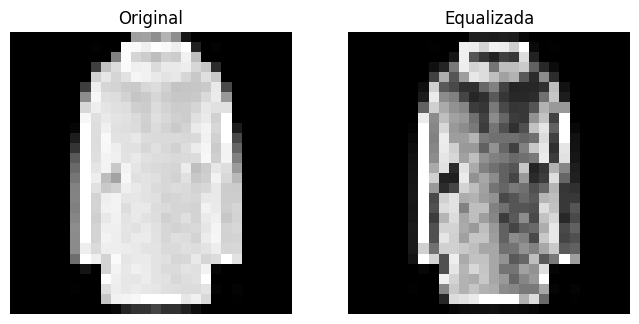

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = 6
# Guarda a imagem original
imagem_original = (X[img, :, :, 0] * 255).astype(np.uint8)

# Dataset para armazenar as imagens equalizadas
X_eq = np.empty_like(X)

for i in range(len(X)):
    imagem = (X[i, :, :, 0] * 255).astype(np.uint8)

    imagem_eq = cv2.equalizeHist(imagem)

    # Volta para o intervalo [0,1]
    X_eq[i, :, :, 0] = imagem_eq / 255.0

# Imagem equalizada
imagem_equalizada = X_eq[img, :, :, 0]

# Comparação
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(imagem_original, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(imagem_equalizada, cmap='gray')
plt.title("Equalizada")
plt.axis('off')

plt.show()

# Atualiza o dataset
X = X_eq

#Separação de Dados

Será novamente separado os dados entre treino e teste, por questões de demonstrar tal funcionalidade e estuda-la. Além disso, essa é uma técnica importante, já que ao utilizar as mesmas imagens tanto no treinamento quanto no teste, ele terá uma alta taxa de acerto apenas porque memorizou os dados, porem nao se sabe se conseguiu realmente aprender a identificar padrões.

In [ ]:
from sklearn.model_selection import train_test_split

#Separação entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

print("Rótulos treino:", y_train.shape)
print("Rótulos teste:", y_test.shape)

Treino: (56000, 28, 28, 1)
Teste: (14000, 28, 28, 1)
Rótulos treino: (56000,)
Rótulos teste: (14000,)


Foi utilizada essa proporção, ja que diante pesquisas, essa é a proporção mais utilizada, por ter uma grande quantidade de imagens para treino, formando o modelo que consegue aprender os padrões, e por outro lado uma quantidade de teste razoávelmente grande com imagens não utilizadas antes, mantendo a confiança do teste.

Além disso a estratificação com base no y foi útil para não ter quantidades desproporcionais de imagens de mesma classe na separação entre teste e treino, podendo ter muitas para teste, e haver pouco ou nennhum para treino. Foi feito em y já que, o importante é ter proporção na quantidade de imagens da mesma classe, e o y é o label que mostra a classe.

In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for fold, (train_index, val_index) in enumerate(skf.split(X, y), start=1):

    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    print(f"----- Fold {fold} -----")

    # Tamanho dos conjuntos
    print("Treino:", X_train.shape)
    print("Validação:", X_val.shape)

    # Distribuição das classes
    print("Classes treino:", np.bincount(y_train))
    print("Classes validação:", np.bincount(y_val))
    print()

----- Fold 1 -----
Treino: (56000, 28, 28, 1)
Validação: (14000, 28, 28, 1)
Classes treino: [5601 5602 5594 5596 5599 5603 5595 5601 5607 5602]
Classes validação: [1401 1400 1399 1398 1400 1401 1398 1400 1402 1401]

----- Fold 2 -----
Treino: (56000, 28, 28, 1)
Validação: (14000, 28, 28, 1)
Classes treino: [5602 5602 5594 5595 5599 5603 5594 5601 5607 5603]
Classes validação: [1400 1400 1399 1399 1400 1401 1399 1400 1402 1400]

----- Fold 3 -----
Treino: (56000, 28, 28, 1)
Validação: (14000, 28, 28, 1)
Classes treino: [5602 5602 5594 5595 5599 5603 5594 5600 5608 5603]
Classes validação: [1400 1400 1399 1399 1400 1401 1399 1401 1401 1400]

----- Fold 4 -----
Treino: (56000, 28, 28, 1)
Validação: (14000, 28, 28, 1)
Classes treino: [5602 5601 5595 5595 5599 5604 5594 5601 5607 5602]
Classes validação: [1400 1401 1398 1399 1400 1400 1399 1400 1402 1401]

----- Fold 5 -----
Treino: (56000, 28, 28, 1)
Validação: (14000, 28, 28, 1)
Classes treino: [5601 5601 5595 5595 5600 5603 5595 5601 560

A validação cruzada se mostra adequada ao mostrar uma avaliaçao confiavel, já que reduz a influência de uma única divisão dos dados. Ela utiliza diferentes subconjuntos para treino e validação, gerando resultados mais estáveis e permitindo uma comparação mais justa entre modelos.

# Modelagem

Foram utilizados um modelo baseline (DummyClassifier) para servir como referência de desempenho e dois modelos de aprendizado de máquina: SGDClassifier e RandomForestClassifier. Ao final, os modelos treinados foram comparados e o de melhor desempenho foi escolhido como modelo final.



**Preparação dos dados**

Tendo como base que os modelos utilizados trabalham com dados que são organizados em forma de tabela, cada imagem de 28 x 28 foi convertida em um vetor de 784 valores, permitindo seu uso pelos classificadores do scikit-learn.

In [ ]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

print("Shape treino (flat):", X_train_flat.shape)
print("Shape teste  (flat):", X_test_flat.shape)

Shape treino (flat): (56000, 784)
Shape teste  (flat): (14000, 784)


**Baseline**

O DummyClassifier foi utilizado como um modelo de referência. Pelo fato de sempre prevê a classe mais frequente do conjunto de treinamento, esse modelo permite verificar se os demais modelos conseguem aprender padrões presentes nos dados.

In [ ]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(X_train_flat, y_train)
y_pred_baseline = baseline.predict(X_test_flat)

print("Baseline treinado.")

Baseline treinado.


**Modelos Escolhidos:**

**SGDClassifier**

Modelo linear treinado por gradiente descendente estocástico. Neste caso foi utilizada a função de perda hinge, equivalente a uma SVM linear.

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(
    loss="hinge",
    max_iter=30,
    random_state=42,
    n_jobs=-1
)
sgd.fit(X_train_flat, y_train)
y_pred_sgd = sgd.predict(X_test_flat)

print("SGDClassifier treinado.")

SGDClassifier treinado.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


**Random Forest**

Conjunto de árvores de decisão que trabalham em conjunto. A classificação final é obtida pela votação entre as árvores, tornando o modelo mais robusto e reduzindo o risco de decisões baseadas em apenas uma árvore.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_flat, y_train)
y_pred_rf = rf.predict(X_test_flat)

print("RandomForestClassifier treinado.")

RandomForestClassifier treinado.


**Comparação dos modelos**

A acurácia é utilizada para comparar o desempenho
dos modelos sobre o conjunto de teste reservado.

In [ ]:
from sklearn.metrics import accuracy_score
import pandas as pd

resultados = {
    "Modelo": ["Baseline (DummyClassifier)", "SGDClassifier", "RandomForestClassifier"],
    "Acurácia": [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_sgd),
        accuracy_score(y_test, y_pred_rf),
    ]
}

df_resultados = pd.DataFrame(resultados)
df_resultados["Acurácia"] = df_resultados["Acurácia"].map(lambda x: f"{x:.4f} ({x*100:.2f}%)")
print("\nComparação de acurácia:")
print(df_resultados.to_string(index=False))


Comparação de acurácia:
                    Modelo        Acurácia
Baseline (DummyClassifier) 0.1001 (10.01%)
             SGDClassifier 0.8496 (84.96%)
    RandomForestClassifier 0.9801 (98.01%)


**Justificativa**

O RandomForestClassifier apresentou a maior acurácia entre os modelos avaliados e, por isso, foi escolhido como modelo final. O DummyClassifier foi utilizado apenas como baseline, enquanto o SGDClassifier apresentou desempenho intermediário. Dessa forma, o RandomForestClassifier foi considerado o modelo mais adequado para este conjunto de dados.